# Feature selection (definitive analysis)

Single notebook for the process: availability, lag correlations, **F1–F5** ablation, and **`seq_len`** (target ACF).

1. Set `ZONE` and `CONTAMINANT`.
2. Run all cells.
3. At the end: keep / review / drop, F1–F5 feature lists, and recommended `seq_len`.

Output: `analysis/feature_selection/zone_<n>/<CONT>/`  
(Reference ACF also written to `analysis/acf/zone_<n>/<CONT>/`)

> F1–F5 lists are aligned with `src/data/feature_configs.py` (training).


In [19]:
# ===== CONFIG =====
ZONE = 2
CONTAMINANT = "PM10"  # NO2, SO2, PM10, CO, O3, NO, PM25, NOx
START_DATE = "2019-01-01"
MIN_AVAILABILITY = 80.0
LAGS = [1, 3, 6, 12, 24, 48]
HORIZON = 24
MAX_LAG = 168
ACF_THRESHOLD = 0.3
MIN_SEQ_LEN = 24
SEQ_LEN_CANDIDATES = [12, 24, 48, 72, 96, 168]

from pathlib import Path
import json
import sys
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "data" / "training").is_dir():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find data/training/. "
        "Open the notebook from the MASTER repo or change the kernel cwd."
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATASET_PATH = ROOT / f"data/training/zone_{ZONE}/dataset_zone_{ZONE}_{CONTAMINANT}.csv"
OUTPUT_DIR = ROOT / f"analysis/feature_selection/zone_{ZONE}/{CONTAMINANT}"
ACF_DIR = ROOT / f"analysis/acf/zone_{ZONE}/{CONTAMINANT}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ACF_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found:\n  {DATASET_PATH}\n"
        f"Build the definitive CSV for zone {ZONE} / {CONTAMINANT}."
    )

print(f"Zone        : {ZONE}")
print(f"Contaminant : {CONTAMINANT}")
print(f"ROOT        : {ROOT}")
print(f"Dataset     : {DATASET_PATH.relative_to(ROOT)}")
print(f"Output      : {OUTPUT_DIR.relative_to(ROOT)}")
print(f"ACF         : {ACF_DIR.relative_to(ROOT)}")
print(f"Horizon     : {HORIZON} h")


Zone        : 2
Contaminant : PM10
ROOT        : C:\Users\105116\MASTER
Dataset     : data\training\zone_2\dataset_zone_2_PM10.csv
Output      : analysis\feature_selection\zone_2\PM10
ACF         : analysis\acf\zone_2\PM10
Horizon     : 24 h


## 1. F1–F5 definitions and candidates

Same logic as `feature_configs.py` (used later for training).


In [20]:
AQ_CANDIDATES = ["PM10", "PM25", "NO2", "NO", "NOx", "SO2", "CO", "O3"]
METEO_CANDIDATES = ["VV", "wind_sin", "wind_cos", "T", "H", "PR", "LL", "RA"]
TIME_FEATURES = [
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos",
]
METEO_F3 = ["VV", "wind_sin", "wind_cos", "T", "H", "PR"]

F4_ADDITIONS = {
    "PM10": ["PM25", "NO2", "NOx", "SO2"],
    "PM25": ["PM10", "NO2", "NOx", "SO2"],
    "NO2": ["PM10", "PM25", "NOx", "SO2"],
    "NOx": ["PM10", "PM25", "NO2", "SO2"],
    "SO2": ["PM10", "PM25", "NO2", "NOx"],
    "CO": ["PM10", "PM25", "NO2", "NOx"],
    "O3": ["PM10", "NO2", "NOx", "SO2"],
    "NO": ["PM10", "NO2", "NOx", "SO2"],
}
DEFAULT_F4 = ["PM25", "NO2", "NOx", "SO2"]
ABLATION_LEVELS = ["F1", "F2", "F3", "F4", "F5"]
LEVEL_DESCRIPTIONS = {
    "F1": "Autoregressive (target only)",
    "F2": "Target + time features",
    "F3": "F2 + meteorology",
    "F4": "F3 + other pollutants",
    "F5": "F4 + Saharan dust (Sah)",
}


@dataclass(frozen=True)
class FeatureConfig:
    contaminant: str
    level: str
    target: str
    features: tuple
    description: str


def f4_pollutants_for(contaminant):
    extras = F4_ADDITIONS.get(contaminant, DEFAULT_F4)
    return [c for c in extras if c != contaminant]


def build_feature_list(contaminant, level):
    features = [contaminant]
    if level in {"F2", "F3", "F4", "F5"}:
        features.extend(TIME_FEATURES)
    if level in {"F3", "F4", "F5"}:
        features.extend(METEO_F3)
    if level in {"F4", "F5"}:
        features.extend(f4_pollutants_for(contaminant))
    if level == "F5":
        features.append("Sah")
    # unique, preserve order
    seen, ordered = set(), []
    for col in features:
        if col not in seen:
            seen.add(col)
            ordered.append(col)
    return ordered


def get_feature_config(contaminant, level):
    return FeatureConfig(
        contaminant=contaminant,
        level=level,
        target=contaminant,
        features=tuple(build_feature_list(contaminant, level)),
        description=LEVEL_DESCRIPTIONS[level],
    )


# Check alignment with feature_configs.py (training)
from src.data import feature_configs as fc

for level in ABLATION_LEVELS:
    nb_feats = list(get_feature_config(CONTAMINANT, level).features)
    py_feats = list(fc.get_feature_config(CONTAMINANT, level).features)
    assert nb_feats == py_feats, f"Mismatch at {level}:\n  nb={nb_feats}\n  py={py_feats}"

print("F1–F5 aligned with feature_configs.py")
for level in ABLATION_LEVELS:
    cfg = get_feature_config(CONTAMINANT, level)
    print(f"  {level}: {cfg.description} → {list(cfg.features)}")


F1–F5 aligned with feature_configs.py
  F1: Autoregressive (target only) → ['PM10']
  F2: Target + time features → ['PM10', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
  F3: F2 + meteorology → ['PM10', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'VV', 'wind_sin', 'wind_cos', 'T', 'H', 'PR']
  F4: F3 + other pollutants → ['PM10', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'VV', 'wind_sin', 'wind_cos', 'T', 'H', 'PR', 'PM25', 'NO2', 'NOx', 'SO2']
  F5: F4 + Saharan dust (Sah) → ['PM10', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'VV', 'wind_sin', 'wind_cos', 'T', 'H', 'PR', 'PM25', 'NO2', 'NOx', 'SO2', 'Sah']


## 2. Analysis functions

Availability, lag correlations, ranking, ACF → `seq_len`.


In [21]:
def load_dataset(path, start_date):
    df = pd.read_csv(path, parse_dates=["time"], low_memory=False)
    df = df[df["time"] >= pd.Timestamp(start_date)].copy()
    return df.sort_values(["time", "ID"]).reset_index(drop=True)


def add_derived_features(df):
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])
    out["hour"] = out["time"].dt.hour
    out["dow"] = out["time"].dt.dayofweek
    out["month"] = out["time"].dt.month
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["dow_sin"] = np.sin(2 * np.pi * out["dow"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dow"] / 7)
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    if "DV" in out.columns:
        out["wind_sin"] = np.sin(np.deg2rad(out["DV"]))
        out["wind_cos"] = np.cos(np.deg2rad(out["DV"]))
    return out


def candidate_columns(df, target):
    pool = list(dict.fromkeys(
        AQ_CANDIDATES + METEO_CANDIDATES + TIME_FEATURES + ["Sah", "LL", "RA"]
    ))
    return [c for c in pool if c in df.columns and c != target]


def availability_table(df, columns):
    rows = []
    for col in columns:
        if col not in df.columns:
            continue
        by_station = df.groupby("ID")[col].apply(lambda s: s.notna().mean() * 100)
        rows.append({
            "variable": col,
            "availability_mean_pct": round(float(by_station.mean()), 2),
            "availability_min_pct": round(float(by_station.min()), 2),
            "availability_max_pct": round(float(by_station.max()), 2),
            "n_stations": int(by_station.shape[0]),
        })
    return (
        pd.DataFrame(rows)
        .sort_values("availability_mean_pct", ascending=False)
        .reset_index(drop=True)
    )


def lag_correlation_table(df, target, candidates, lags, include_target=True):
    vars_to_test = list(candidates)
    if include_target and target in df.columns and target not in vars_to_test:
        vars_to_test = [target] + vars_to_test
    rows = []
    for station_name, group in df.groupby("station_name"):
        group = group.sort_values("time")
        y = group[target]
        for var in vars_to_test:
            if var not in group.columns:
                continue
            for lag in lags:
                corr = group[var].shift(lag).corr(y)
                if pd.isna(corr):
                    continue
                rows.append({
                    "station_name": station_name,
                    "variable": var,
                    "lag_hours": lag,
                    "correlation": round(float(corr), 4),
                })
    lag_df = pd.DataFrame(rows)
    if lag_df.empty:
        return lag_df
    summary = (
        lag_df.groupby(["variable", "lag_hours"])["correlation"]
        .agg(["mean", "min", "max", "count"])
        .reset_index()
        .rename(columns={
            "mean": "corr_mean", "min": "corr_min",
            "max": "corr_max", "count": "n_stations",
        })
    )
    for c in ["corr_mean", "corr_min", "corr_max"]:
        summary[c] = summary[c].round(4)
    return summary.sort_values(["variable", "lag_hours"]).reset_index(drop=True)


def ranking_table(lag_corr, avail, target, min_availability_pct):
    if lag_corr.empty:
        return pd.DataFrame()
    best_rows = []
    for var, g in lag_corr.groupby("variable"):
        g = g.copy()
        g["abs_corr"] = g["corr_mean"].abs()
        best = g.loc[g["abs_corr"].idxmax()]

        def lag_val(lag):
            m = g.loc[g["lag_hours"] == lag, "corr_mean"]
            return float(m.iloc[0]) if len(m) else np.nan

        best_rows.append({
            "variable": var,
            "is_target": var == target,
            "best_lag_hours": int(best["lag_hours"]),
            "corr_at_best_lag": float(best["corr_mean"]),
            "abs_corr_at_best_lag": float(best["abs_corr"]),
            "corr_lag1": lag_val(1),
            "corr_lag24": lag_val(24),
            "corr_lag48": lag_val(48),
        })
    rank = pd.DataFrame(best_rows)
    avail_map = avail.set_index("variable")["availability_mean_pct"].to_dict()
    min_map = avail.set_index("variable")["availability_min_pct"].to_dict()
    rank["availability_mean_pct"] = rank["variable"].map(avail_map)
    rank["availability_min_pct"] = rank["variable"].map(min_map)
    rank["passes_availability"] = (
        rank["availability_mean_pct"].fillna(0) >= min_availability_pct
    )
    rank = rank.sort_values(
        ["is_target", "abs_corr_at_best_lag"], ascending=[False, False]
    ).reset_index(drop=True)
    rank["rank"] = np.arange(1, len(rank) + 1)
    return rank


def compute_acf(series, max_lag):
    centered = series - series.mean()
    acf = np.ones(max_lag + 1, dtype=np.float64)
    for lag in range(1, max_lag + 1):
        if lag >= len(centered):
            acf[lag:] = np.nan
            break
        acf[lag] = np.corrcoef(centered[:-lag], centered[lag:])[0, 1]
    return acf


def first_lag_below(acf, threshold):
    for lag in range(1, len(acf)):
        if np.isnan(acf[lag]):
            break
        if acf[lag] < threshold:
            return lag
    return None


def round_up_to_candidate(value, candidates):
    for c in candidates:
        if c >= value:
            return c
    return candidates[-1]


def recommend_seq_len(median_acf, horizon, acf_threshold, min_seq_len, candidates):
    memory_lag = first_lag_below(median_acf, acf_threshold)
    if memory_lag is None:
        memory_lag = len(median_acf) - 1
    lower_bound = max(min_seq_len, horizon, memory_lag)
    recommended = round_up_to_candidate(lower_bound, candidates)
    key_lags = [1, 6, 12, 24, 48, 72, 96, 120, 168]
    acf_at_key = {
        str(lag): float(median_acf[lag])
        for lag in key_lags
        if lag < len(median_acf) and not np.isnan(median_acf[lag])
    }
    return {
        "recommended_seq_len": recommended,
        "memory_lag_hours": memory_lag,
        "acf_threshold": acf_threshold,
        "horizon": horizon,
        "min_seq_len": min_seq_len,
        "lower_bound_hours": lower_bound,
        "candidates": candidates,
        "acf_at_key_lags": acf_at_key,
        "median_acf_lag1": round(float(median_acf[1]), 4),
        "median_acf_lag24": round(float(median_acf[24]), 4) if len(median_acf) > 24 else None,
        "median_acf_lag48": round(float(median_acf[48]), 4) if len(median_acf) > 48 else None,
        "rationale": (
            f"First lag with ACF<{acf_threshold}: {memory_lag} h; "
            f"operational minimum max({min_seq_len}, {horizon}) h; "
            f"chosen candidate: {recommended} h"
        ),
    }


def features_used_for_level(avail, contaminant, level, min_availability_pct):
    avail_map = avail.set_index("variable")["availability_mean_pct"].to_dict()
    config = get_feature_config(contaminant, level)
    used, excluded = [], []
    for col in config.features:
        pct = avail_map.get(col)
        if pct is None:
            excluded.append(f"{col}(missing)")
        elif pct >= min_availability_pct:
            used.append(col)
        else:
            excluded.append(f"{col}({pct:.1f}%)")
    return used, excluded


print("Functions loaded.")


Functions loaded.


## 3. Load data and compute tables


In [22]:
raw = load_dataset(DATASET_PATH, START_DATE)
df = add_derived_features(raw)
target = CONTAMINANT
candidates = candidate_columns(df, target)

avail = availability_table(df, [target] + candidates)
lag_corr = lag_correlation_table(df, target, candidates, LAGS, include_target=True)
ranking = ranking_table(lag_corr, avail, target, MIN_AVAILABILITY)

# F1–F5 ablation (features by availability)
ablation_rows = []
for level in ABLATION_LEVELS:
    config = get_feature_config(CONTAMINANT, level)
    used, excluded = features_used_for_level(
        avail, CONTAMINANT, level, MIN_AVAILABILITY
    )
    ablation_rows.append({
        "level": level,
        "description": config.description,
        "n_requested": len(config.features),
        "n_used": len(used),
        "features_used": "; ".join(used),
        "features_excluded": "; ".join(excluded),
    })
ablation = pd.DataFrame(ablation_rows)

# Single seq_len (target ACF, all stations with data)
series_by_station = {}
station_rows = []
for station_name, group in df.groupby("station_name", sort=True):
    values = group.sort_values("time")[target].dropna().to_numpy(dtype=np.float64)
    if len(values) <= 1:
        continue
    series_by_station[station_name] = values
    acf_st = compute_acf(values, MAX_LAG)
    station_rows.append({
        "station_name": station_name,
        "n_obs": len(values),
        "acf_lag1": round(float(acf_st[1]), 4),
        "acf_lag24": round(float(acf_st[24]), 4),
        "memory_lag_hours": first_lag_below(acf_st, ACF_THRESHOLD),
    })

acf_list = [compute_acf(s, MAX_LAG) for s in series_by_station.values()]
acf_matrix = np.vstack(acf_list)
median_acf = np.nanmedian(acf_matrix, axis=0)
seq_rec = recommend_seq_len(
    median_acf, HORIZON, ACF_THRESHOLD, MIN_SEQ_LEN, SEQ_LEN_CANDIDATES
)
seq_rec["n_stations"] = len(series_by_station)
seq_rec["zone"] = ZONE
seq_rec["contaminant"] = CONTAMINANT

lag_acf_df = pd.DataFrame({
    "lag_hours": np.arange(len(median_acf)),
    "acf_median": median_acf,
    "acf_mean": np.nanmean(acf_matrix, axis=0),
    "acf_p25": np.nanpercentile(acf_matrix, 25, axis=0),
    "acf_p75": np.nanpercentile(acf_matrix, 75, axis=0),
})
station_acf_df = pd.DataFrame(station_rows).sort_values("station_name")

# keep / review / drop
predictors = ranking[~ranking["is_target"]].copy()
keep = predictors[predictors["passes_availability"]]
review = predictors[
    (~predictors["passes_availability"])
    & (predictors["availability_mean_pct"].fillna(0) >= 60)
]
drop = predictors[predictors["availability_mean_pct"].fillna(0) < 60]

print(f"Stations: {len(series_by_station)}")
print(f"Recommended seq_len: {seq_rec['recommended_seq_len']} h")
print(f"  ({seq_rec['rationale']})")


Stations: 18
Recommended seq_len: 48 h
  (First lag with ACF<0.3: 30 h; operational minimum max(24, 24) h; chosen candidate: 48 h)


## 4. Availability


,variable,availability_mean_pct,availability_min_pct,availability_max_pct,n_stations
0,hour_sin,100.00,100.00,100.0,18
1,PR,100.00,100.00,100.0,18
2,LL,100.00,100.00,100.0,18
3,T,100.00,100.00,100.0,18
4,wind_cos,100.00,100.00,100.0,18
5,wind_sin,100.00,100.00,100.0,18
6,VV,100.00,100.00,100.0,18
7,dow_cos,100.00,100.00,100.0,18
8,month_sin,100.00,100.00,100.0,18
9,hour_cos,100.00,100.00,100.0,18


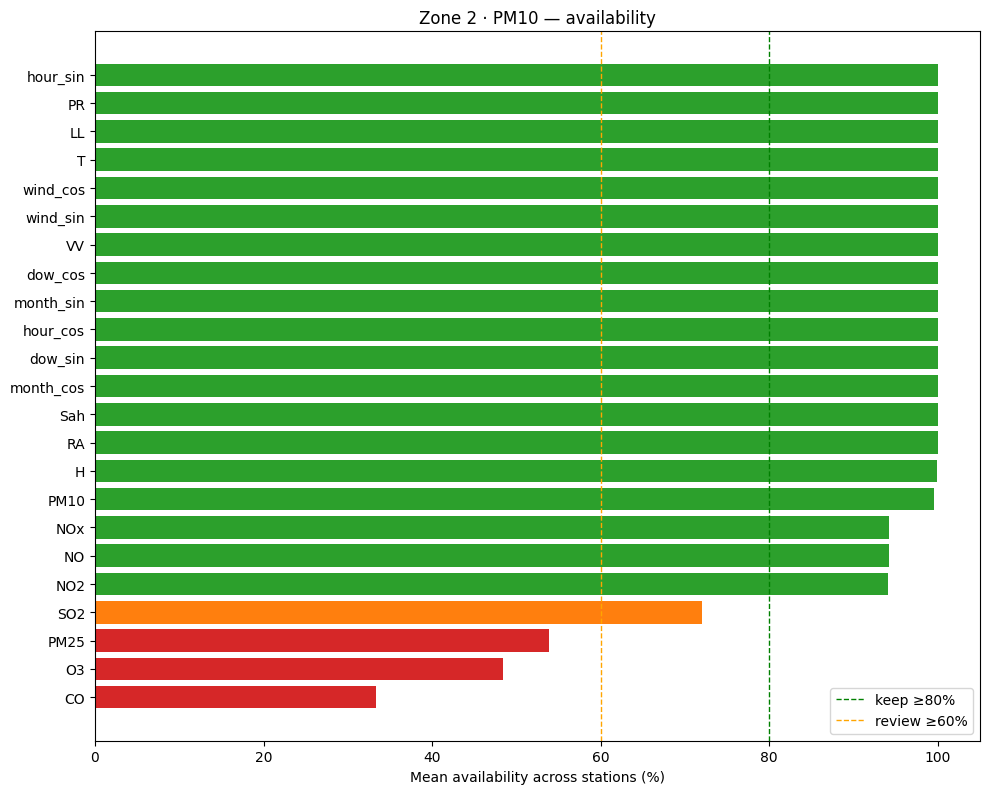

In [23]:
display(avail)

fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(avail))))
colors = [
    "#2ca02c" if v >= MIN_AVAILABILITY else ("#ff7f0e" if v >= 60 else "#d62728")
    for v in avail["availability_mean_pct"]
]
ax.barh(avail["variable"][::-1], avail["availability_mean_pct"][::-1], color=colors[::-1])
ax.axvline(MIN_AVAILABILITY, color="green", linestyle="--", linewidth=1,
           label=f"keep ≥{MIN_AVAILABILITY:.0f}%")
ax.axvline(60, color="orange", linestyle="--", linewidth=1, label="review ≥60%")
ax.set_xlabel("Mean availability across stations (%)")
ax.set_title(f"Zone {ZONE} · {CONTAMINANT} — availability")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "availability_plot.png", dpi=140)
plt.show()


## 5. Lag correlations


lag_hours,1,3,6,12,24,48
variable,,,,,,
CO,0.276,0.225,0.176,0.142,0.133,0.090
H,0.023,0.012,0.004,0.000,-0.013,-0.000
LL,-0.089,-0.093,-0.085,-0.074,-0.063,-0.052
NO,0.249,0.188,0.104,0.070,0.113,0.064
NO2,0.350,0.291,0.207,0.154,0.172,0.111
NOx,0.335,0.267,0.170,0.123,0.160,0.098
O3,-0.058,-0.052,-0.031,-0.003,-0.010,-0.000
PM10,0.866,0.692,0.558,0.426,0.392,0.250
PM25,0.680,0.565,0.467,0.362,0.338,0.216


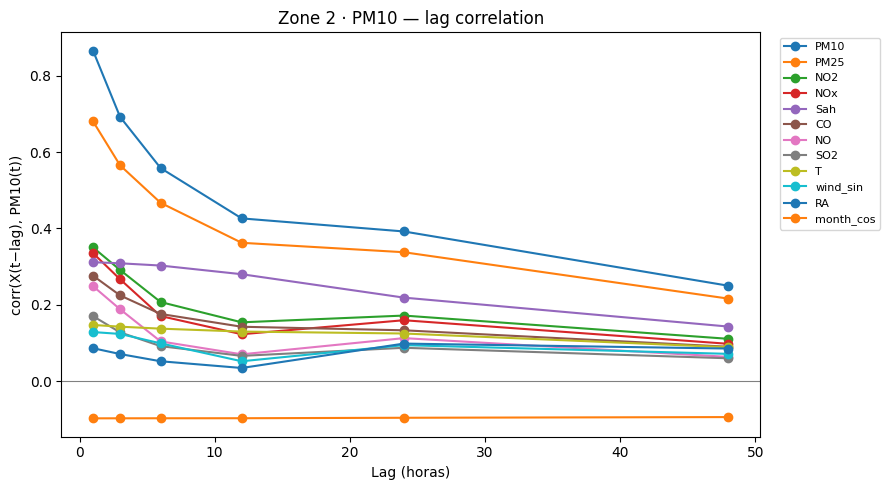

In [24]:
pivot = lag_corr.pivot(index="variable", columns="lag_hours", values="corr_mean")
display(pivot.round(3))

pred_rank = ranking[~ranking["is_target"]].head(12)["variable"].tolist()
plot_vars = [CONTAMINANT] + [v for v in pred_rank if v != CONTAMINANT]
plot_vars = [v for v in plot_vars if v in pivot.index][:12]

fig, ax = plt.subplots(figsize=(9, 5))
for var in plot_vars:
    ax.plot(pivot.columns, pivot.loc[var], marker="o", label=var)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Lag (horas)")
ax.set_ylabel(f"corr(X(t−lag), {CONTAMINANT}(t))")
ax.set_title(f"Zone {ZONE} · {CONTAMINANT} — lag correlation")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "lag_correlation_plot.png", dpi=140, bbox_inches="tight")
plt.show()


## 6. Ranking


In [25]:
cols = [
    "rank", "variable", "is_target", "best_lag_hours", "corr_at_best_lag",
    "corr_lag1", "corr_lag24", "corr_lag48",
    "availability_mean_pct", "passes_availability",
]
display(ranking[cols])


,rank,variable,is_target,best_lag_hours,corr_at_best_lag,corr_lag1,corr_lag24,corr_lag48,availability_mean_pct,passes_availability
0,1,PM10,True,1,0.8655,0.8655,0.3921,0.2500,99.58,True
1,2,PM25,False,1,0.6804,0.6804,0.3377,0.2162,53.87,False
2,3,NO2,False,1,0.3503,0.3503,0.1718,0.1109,94.14,True
3,4,NOx,False,1,0.3353,0.3353,0.1596,0.0978,94.23,True
4,5,Sah,False,1,0.3116,0.3116,0.2188,0.1430,100.00,True
5,6,CO,False,1,0.2762,0.2762,0.1332,0.0901,33.32,False
6,7,NO,False,1,0.2487,0.2487,0.1127,0.0636,94.15,True
7,8,SO2,False,1,0.1703,0.1703,0.0874,0.0599,72.06,False
8,9,T,False,1,0.1472,0.1472,0.1248,0.0889,100.00,True
9,10,wind_sin,False,1,0.1286,0.1286,0.0943,0.0715,100.00,True


## 7. F1–F5 ablation (training feature sets)


In [26]:
display(ablation)

for _, row in ablation.iterrows():
    print(f"\n{row['level']} — {row['description']}")
    print(f"  used ({row['n_used']}/{row['n_requested']}): {row['features_used']}")
    if row["features_excluded"]:
        print(f"  excluded: {row['features_excluded']}")


,level,description,n_requested,n_used,features_used,features_excluded
0,F1,Autoregressive (target only),1,1,PM10,
1,F2,Target + time features,7,7,PM10; hour_sin; hour_cos; dow_sin; dow_cos; mo...,
2,F3,F2 + meteorology,13,13,PM10; hour_sin; hour_cos; dow_sin; dow_cos; mo...,
3,F4,F3 + other pollutants,17,15,PM10; hour_sin; hour_cos; dow_sin; dow_cos; mo...,PM25(53.9%); SO2(72.1%)
4,F5,F4 + Saharan dust (Sah),18,16,PM10; hour_sin; hour_cos; dow_sin; dow_cos; mo...,PM25(53.9%); SO2(72.1%)



F1 — Autoregressive (target only)
  used (1/1): PM10

F2 — Target + time features
  used (7/7): PM10; hour_sin; hour_cos; dow_sin; dow_cos; month_sin; month_cos

F3 — F2 + meteorology
  used (13/13): PM10; hour_sin; hour_cos; dow_sin; dow_cos; month_sin; month_cos; VV; wind_sin; wind_cos; T; H; PR

F4 — F3 + other pollutants
  used (15/17): PM10; hour_sin; hour_cos; dow_sin; dow_cos; month_sin; month_cos; VV; wind_sin; wind_cos; T; H; PR; NO2; NOx
  excluded: PM25(53.9%); SO2(72.1%)

F5 — F4 + Saharan dust (Sah)
  used (16/18): PM10; hour_sin; hour_cos; dow_sin; dow_cos; month_sin; month_cos; VV; wind_sin; wind_cos; T; H; PR; NO2; NOx; Sah
  excluded: PM25(53.9%); SO2(72.1%)


## 8. `seq_len` (target ACF)

One `seq_len` per zone/contaminant: the lookback is set by **target** memory, not by the F1–F5 feature set.


,seq_len,memory_lag_hours,horizon,n_stations,acf_lag1,acf_lag24,acf_lag48
0,48,30,24,18,0.8632,0.3887,0.2367


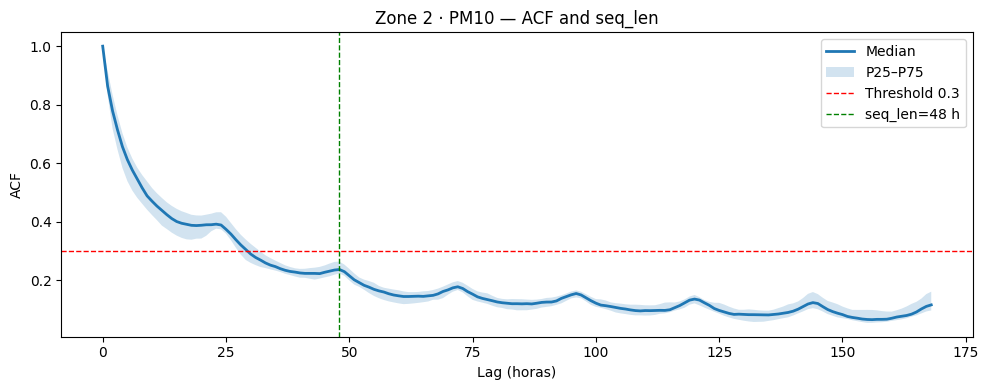


>>> Recommended seq_len: 48 h <<<
Reason: First lag with ACF<0.3: 30 h; operational minimum max(24, 24) h; chosen candidate: 48 h


In [27]:
display(pd.DataFrame([{
    "seq_len": seq_rec["recommended_seq_len"],
    "memory_lag_hours": seq_rec["memory_lag_hours"],
    "horizon": seq_rec["horizon"],
    "n_stations": seq_rec["n_stations"],
    "acf_lag1": seq_rec["median_acf_lag1"],
    "acf_lag24": seq_rec["median_acf_lag24"],
    "acf_lag48": seq_rec["median_acf_lag48"],
}]))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lag_acf_df["lag_hours"], lag_acf_df["acf_median"], label="Median", linewidth=2)
ax.fill_between(
    lag_acf_df["lag_hours"], lag_acf_df["acf_p25"], lag_acf_df["acf_p75"],
    alpha=0.2, label="P25–P75",
)
ax.axhline(ACF_THRESHOLD, color="red", linestyle="--", linewidth=1,
           label=f"Threshold {ACF_THRESHOLD}")
ax.axvline(seq_rec["recommended_seq_len"], color="green", linestyle="--", linewidth=1,
           label=f"seq_len={seq_rec['recommended_seq_len']} h")
ax.set_xlabel("Lag (horas)")
ax.set_ylabel("ACF")
ax.set_title(f"Zone {ZONE} · {CONTAMINANT} — ACF and seq_len")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "acf_plot.png", dpi=140)
fig.savefig(ACF_DIR / "acf_plot.png", dpi=140)
plt.show()

print(f"\n>>> Recommended seq_len: {seq_rec['recommended_seq_len']} h <<<")
print(f"Reason: {seq_rec['rationale']}")


## 9. Save outputs and summary

This section also **recommends which F-level to use next**:

- **F1** — always the baseline (target history only)
- **Default** — richest practical config given availability (often F5 for PM10)
- **Ablation set** — F-levels worth training to see what actually helps


In [28]:
# Feature-selection tables
avail.to_csv(OUTPUT_DIR / "01_availability.csv", index=False)
lag_corr.to_csv(OUTPUT_DIR / "02_lag_correlations.csv", index=False)
ranking.to_csv(OUTPUT_DIR / "03_ranking.csv", index=False)
ablation.to_csv(OUTPUT_DIR / "04_ablation_readiness.csv", index=False)

# ACF / seq_len (also under analysis/acf for --auto-seq-len)
lag_acf_df.to_csv(OUTPUT_DIR / "acf_by_lag.csv", index=False)
station_acf_df.to_csv(OUTPUT_DIR / "acf_by_station.csv", index=False)
lag_acf_df.to_csv(ACF_DIR / "acf_by_lag.csv", index=False)
station_acf_df.to_csv(ACF_DIR / "acf_by_station.csv", index=False)

seq_payload = {
    "dataset": str(DATASET_PATH.as_posix()),
    "target_col": CONTAMINANT,
    "start_date": START_DATE,
    **{k: v for k, v in seq_rec.items() if k not in {"zone", "contaminant"}},
}
with open(OUTPUT_DIR / "seq_len_recommendation.json", "w", encoding="utf-8") as f:
    json.dump(seq_payload, f, indent=2)
with open(ACF_DIR / "seq_len_recommendation.json", "w", encoding="utf-8") as f:
    json.dump(seq_payload, f, indent=2)


def recommend_feature_config(ablation_df, contaminant):
    """
    Recommend F-level from availability-filtered ablation rows.

    - baseline: always F1
    - recommended_default: richest practical level (F5→F1) that still includes the target
    - ablation_to_train: F1 + F3 (if ready) + default
    """
    reasons = {
        "F1": "Baseline: target history only (strong autoregressive signal).",
        "F2": "Adds diurnal/weekly/seasonal time encodings.",
        "F3": "Adds meteorology (dispersion / transport drivers).",
        "F4": "Adds co-pollutants that passed availability.",
        "F5": "Adds Saharan-dust flag on top of F4.",
    }

    ready = {}
    for _, row in ablation_df.iterrows():
        feats = [x.strip() for x in str(row["features_used"]).split(";") if x.strip()]
        ready[row["level"]] = {
            "n_used": int(row["n_used"]),
            "n_requested": int(row["n_requested"]),
            "features_used": feats,
            "features_excluded": row["features_excluded"],
            "practical": contaminant in feats,
        }

    recommended_default = "F1"
    for level in ["F5", "F4", "F3", "F2", "F1"]:
        if ready.get(level, {}).get("practical"):
            recommended_default = level
            break

    why_default = []
    excl = ready[recommended_default]["features_excluded"]
    if recommended_default == "F5":
        why_default.append(
            "Main config: F5 (time + meteorology + available co-pollutants + Sah)."
        )
    elif recommended_default == "F4":
        why_default.append(
            "Main config: F4 (time + meteorology + available co-pollutants)."
        )
    elif recommended_default == "F3":
        why_default.append(
            "Main config: F3 (time + meteorology). Co-pollutants/Sah not practical yet."
        )
    elif recommended_default == "F2":
        why_default.append("Main config: F2 (target + time features).")
    else:
        why_default.append("Main config: F1 (only target history is reliably available).")

    if excl:
        why_default.append(f"Excluded by availability at this level: {excl}")

    ablation_to_train = ["F1"]
    if ready.get("F3", {}).get("practical"):
        ablation_to_train.append("F3")
    if recommended_default not in ablation_to_train:
        ablation_to_train.append(recommended_default)

    return {
        "baseline": "F1",
        "recommended_default": recommended_default,
        "ablation_to_train": ablation_to_train,
        "why_default": why_default,
        "level_reasons": {lv: reasons[lv] for lv in ablation_to_train},
        "features_used_default": ready[recommended_default]["features_used"],
    }


f_rec = recommend_feature_config(ablation, CONTAMINANT)

summary = {
    "zone": ZONE,
    "contaminant": CONTAMINANT,
    "dataset": str(DATASET_PATH.as_posix()),
    "start_date": START_DATE,
    "lags_hours": LAGS,
    "min_availability_pct": MIN_AVAILABILITY,
    "horizon": HORIZON,
    "n_stations": int(avail["n_stations"].iloc[0]),
    "seq_len": seq_rec["recommended_seq_len"],
    "seq_len_rationale": seq_rec["rationale"],
    "target_persistence": {
        "corr_lag1": float(ranking.loc[ranking["is_target"], "corr_lag1"].iloc[0]),
        "corr_lag24": float(ranking.loc[ranking["is_target"], "corr_lag24"].iloc[0]),
        "corr_lag48": float(ranking.loc[ranking["is_target"], "corr_lag48"].iloc[0]),
    },
    "variables_keep": keep["variable"].tolist(),
    "variables_review_60_80": review["variable"].tolist(),
    "variables_drop_below_60": drop["variable"].tolist(),
    "ablation_levels": ablation.to_dict(orient="records"),
    "feature_config_recommendation": f_rec,
    "notes": [
        "Self-contained notebook: src/data/feature_selection.ipynb",
        "Single seq_len per zone/contaminant (target ACF).",
        "F1–F5 aligned with feature_configs.py for training.",
        "recommended_default is the main F-level to train next; always keep F1 as baseline.",
    ],
}
with open(OUTPUT_DIR / "feature_selection_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("=" * 60)
print(f"ZONE {ZONE} · {CONTAMINANT}")
print("=" * 60)
print(
    f"Persistence: lag1={summary['target_persistence']['corr_lag1']}, "
    f"lag24={summary['target_persistence']['corr_lag24']}, "
    f"lag48={summary['target_persistence']['corr_lag48']}"
)
print(f"\n>>> KEEP  (≥{MIN_AVAILABILITY:.0f}%): {summary['variables_keep']}")
print(f">>> REVIEW (60–80%): {summary['variables_review_60_80']}")
print(f">>> DROP   (<60%):   {summary['variables_drop_below_60']}")
print(f"\n>>> seq_len = {summary['seq_len']} h <<<")
print(f"    {summary['seq_len_rationale']}")

print("\nF1–F5 readiness:")
for row in summary["ablation_levels"]:
    extra = f" | excluded: {row['features_excluded']}" if row["features_excluded"] else ""
    print(f"  {row['level']}: {row['n_used']}/{row['n_requested']} features{extra}")

print("\n" + "=" * 60)
print("FEATURE CONFIG CHOICE")
print("=" * 60)
print(f">>> Baseline           : {f_rec['baseline']}")
print(f">>> Recommended default: {f_rec['recommended_default']}  <<<  train this next")
print(f">>> Ablation to run    : {f_rec['ablation_to_train']}")
print(f">>> Features in default: {f_rec['features_used_default']}")
print("\nWhy this default:")
for line in f_rec["why_default"]:
    print(f"  - {line}")
print("\nWhat each selected level tests:")
for lv, reason in f_rec["level_reasons"].items():
    print(f"  {lv}: {reason}")

print(f"\nJSON: {OUTPUT_DIR / 'feature_selection_summary.json'}")
print("=" * 60)


ZONE 2 · PM10
Persistence: lag1=0.8655, lag24=0.3921, lag48=0.25

>>> KEEP  (≥80%): ['NO2', 'NOx', 'Sah', 'NO', 'T', 'wind_sin', 'RA', 'month_cos', 'LL', 'VV', 'dow_sin', 'dow_cos', 'PR', 'hour_sin', 'month_sin', 'hour_cos', 'H', 'wind_cos']
>>> REVIEW (60–80%): ['SO2']
>>> DROP   (<60%):   ['PM25', 'CO', 'O3']

>>> seq_len = 48 h <<<
    First lag with ACF<0.3: 30 h; operational minimum max(24, 24) h; chosen candidate: 48 h

F1–F5 readiness:
  F1: 1/1 features
  F2: 7/7 features
  F3: 13/13 features
  F4: 15/17 features | excluded: PM25(53.9%); SO2(72.1%)
  F5: 16/18 features | excluded: PM25(53.9%); SO2(72.1%)

FEATURE CONFIG CHOICE
>>> Baseline           : F1
>>> Recommended default: F5  <<<  train this next
>>> Ablation to run    : ['F1', 'F3', 'F5']
>>> Features in default: ['PM10', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'VV', 'wind_sin', 'wind_cos', 'T', 'H', 'PR', 'NO2', 'NOx', 'Sah']

Why this default:
  - Main config: F5 (time + meteorology + a